<a href="https://colab.research.google.com/github/Dariafer/portfolio_business-process-analysis/blob/main/%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
df = pd.read_csv('SpotifyFeatures.csv')
df = df.iloc[4250:4351]
df

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
4250,World,Manu Chao,Por El Suelo,0UUYX85tfWbpyzzeWowDgO,39,0.089700,0.353,234907,0.9000,0.000044,D,0.918,-6.237,Minor,0.1920,80.232,4/4,0.5730
4251,World,Hindi Zahra,Fascination - Remastered,4w73yjSJ8a1Omghrwu6g6t,28,0.776000,0.689,217173,0.5140,0.009670,D,0.105,-8.164,Major,0.0317,104.038,4/4,0.4330
4252,World,ICF Worship,God of Life,7trkR9as89vMIjtH0doj47,27,0.059700,0.386,300930,0.5080,0.000000,C,0.382,-8.084,Major,0.0304,85.005,4/4,0.0962
4253,World,Elevation Youth,Aftermath of Love,1U5R8KFAt94zdpFskNLksw,28,0.000321,0.520,253280,0.8420,0.000295,B,0.846,-5.743,Major,0.0438,128.029,4/4,0.4650
4254,World,Eivind Aarset,Family Pictures III,2C2Ge1a3EFA6gFT6aOZtmW,24,0.932000,0.254,218147,0.0807,0.916000,G,0.600,-29.166,Major,0.0562,122.832,4/4,0.1730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,World,Don Moen,Be Glorified,27JSz8wMZ6Q4QAh61WwFeb,39,0.072600,0.553,307040,0.7180,0.000003,F,0.152,-6.385,Major,0.0248,87.989,4/4,0.6770
4347,World,Hillsong UNITED,Jesus Lover Of My Soul - Live,3ictund9KuuTsP2kqYvO6v,25,0.127000,0.205,594533,0.5720,0.004150,G,0.108,-11.192,Major,0.0379,169.460,4/4,0.0521
4348,World,Shane & Shane,Lead Me to the Cross,2MSctPrMtna1xYiO2Thsc9,29,0.018300,0.379,260785,0.4720,0.000000,G,0.183,-8.255,Major,0.0316,143.855,4/4,0.2750
4349,World,Kevin Ayers,May I? - 2003 Remastered Version,64DkUADFBHKvEjEbh0cXcl,35,0.777000,0.540,241012,0.3490,0.885000,C,0.118,-17.387,Major,0.0347,107.920,4/4,0.4010


In [ ]:
for column in df.columns:
    print(f"\nАнализ столбца: {column}")

    print(f"Тип данных: {df[column].dtype}")

    if df[column].dtype == 'object':
        print(f"Уникальные значения: {df[column].unique()}")

    if df[column].dtype == 'object' and any(df[column].str.contains(r'[\*\#\,]', na=False)):
        df[column] = df[column].str.replace(r'[\*\#\,]', '', regex=True)

    try:
        df[column] = pd.to_numeric(df[column], errors='ignore')
    except:
        pass

    if pd.api.types.is_numeric_dtype(df[column]):
        print(f"Среднее: {df[column].mean():.2f}")
        print(f"Максимум: {df[column].max()}")
        print(f"Минимум: {df[column].min()}")

print("\nОбработанный DataFrame:")
print(df.head())


Анализ столбца: genre
Тип данных: object
Уникальные значения: ['World']

Анализ столбца: artist_name
Тип данных: object
Уникальные значения: ['Manu Chao' 'Hindi Zahra' 'ICF Worship' 'Elevation Youth' 'Eivind Aarset'
 'Ott' 'Audrey Assad' 'Michael W. Smith' 'David Crowder Band'
 'Tenth Avenue North' 'Esbjörn Svensson Trio' 'Alice Coltrane'
 'Taylor Deupree' 'Travis Cottrell' 'Matt Maher' 'North Point InsideOut'
 'Fela Kuti' 'Gabriel Guedes de Almeida' 'Kaminanda' 'Joepraize'
 'Shakuhachi Sakano' 'Ablaye Cissoko' 'Cesaria Evora' 'Hildur Guðnadóttir'
 'Cocteau Twins' 'Philip Glass' 'Hillsong Worship' 'Planetshakers'
 'Jesus Culture' 'Hillsong UNITED' 'Broadcast' 'Misty Edwards'
 'Desert Dwellers' 'Roedelius' 'Darlene Zschech' 'Le Trio Joubran'
 'Israel & New Breed' 'Sinach' 'Highlands Worship' 'Hailu Mergia'
 'Vineyard Worship' 'Jonathan David Helser' 'Boubacar Traoré'
 'Adoração Central' 'Kick Bong' 'The Fall' 'Nils Frahm' 'Moondog'
 'Don Moen' 'Dean Evenson' 'Cantoma' 'Stars Of The Lid

<ipython-input-2-c580d1c05927>:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[column] = pd.to_numeric(df[column], errors='ignore')


In [ ]:
def analyze_missing_and_outliers(df):
    results = []
    for column in df.columns:
        na_count = df[column].isna().sum()
        na_percent = (na_count / len(df)) * 100
        outlier_percent = np.nan
        if pd.api.types.is_numeric_dtype(df[column]):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
            outlier_percent = (outliers / len(df)) * 100

        results.append({
            'column': column,
            'dtype': df[column].dtype,
            'missing_percent': round(na_percent, 2),
            'outliers_percent': round(outlier_percent, 2) if not np.isnan(outlier_percent) else 'N/A'
        })
    return pd.DataFrame(results)
analysis_result = analyze_missing_and_outliers(df)
print(analysis_result)

              column    dtype  missing_percent outliers_percent
0              genre   object              0.0              N/A
1        artist_name   object              0.0              N/A
2         track_name   object              0.0              N/A
3           track_id   object              0.0              N/A
4         popularity  float64              0.0             2.97
5       acousticness  float64              0.0              0.0
6       danceability  float64              0.0              0.0
7        duration_ms  float64              0.0             4.95
8             energy  float64              0.0              0.0
9   instrumentalness  float64              0.0              0.0
10               key   object              0.0              N/A
11          liveness  float64              0.0            14.85
12          loudness  float64              0.0             7.92
13              mode   object              0.0              N/A
14       speechiness  float64           

In [ ]:
df.describe(include='all')

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,101,101,101,101,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101,101.000000,101.000000,101,101.000000,101.000000,101,101.000000
unique,1,81,101,101,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,2,NaN,NaN,4,NaN
top,World,Jesus Culture,Por El Suelo,0UUYX85tfWbpyzzeWowDgO,NaN,NaN,NaN,NaN,NaN,NaN,G,NaN,NaN,Major,NaN,NaN,4/4,NaN
freq,101,3,1,1,NaN,NaN,NaN,NaN,NaN,NaN,19,NaN,NaN,77,NaN,NaN,82,NaN
mean,NaN,NaN,NaN,NaN,29.386139,0.427795,0.452109,285927.435644,0.498052,0.290046,NaN,0.152476,-9.945158,NaN,0.039477,117.212901,NaN,0.312549
std,NaN,NaN,NaN,NaN,5.057609,0.362653,0.168776,90143.956676,0.267056,0.382000,NaN,0.110754,4.506337,NaN,0.010012,30.745797,NaN,0.234828
min,NaN,NaN,NaN,NaN,21.000000,0.000300,0.100000,58587.000000,0.003960,0.000000,NaN,0.059800,-23.760000,NaN,0.023800,51.857000,NaN,0.025700
25%,NaN,NaN,NaN,NaN,26.000000,0.077800,0.341000,227840.000000,0.292000,0.000002,NaN,0.104000,-12.479000,NaN,0.032700,91.915000,NaN,0.116000
50%,NaN,NaN,NaN,NaN,29.000000,0.349000,0.450000,276590.000000,0.533000,0.001620,NaN,0.120000,-8.746000,NaN,0.037900,115.995000,NaN,0.240000
75%,NaN,NaN,NaN,NaN,33.000000,0.786000,0.568000,344284.000000,0.697000,0.726000,NaN,0.139000,-6.871000,NaN,0.043900,139.207000,NaN,0.467000


Данные duration_ms после фильтрации:
count       101.000000
mean     301724.247525
std      112621.270788
min       58587.000000
25%      227840.000000
50%      276590.000000
75%      353173.000000
max      620942.000000
Name: duration_ms, dtype: float64
Анализируемые столбцы: Index(['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence'],
      dtype='object')


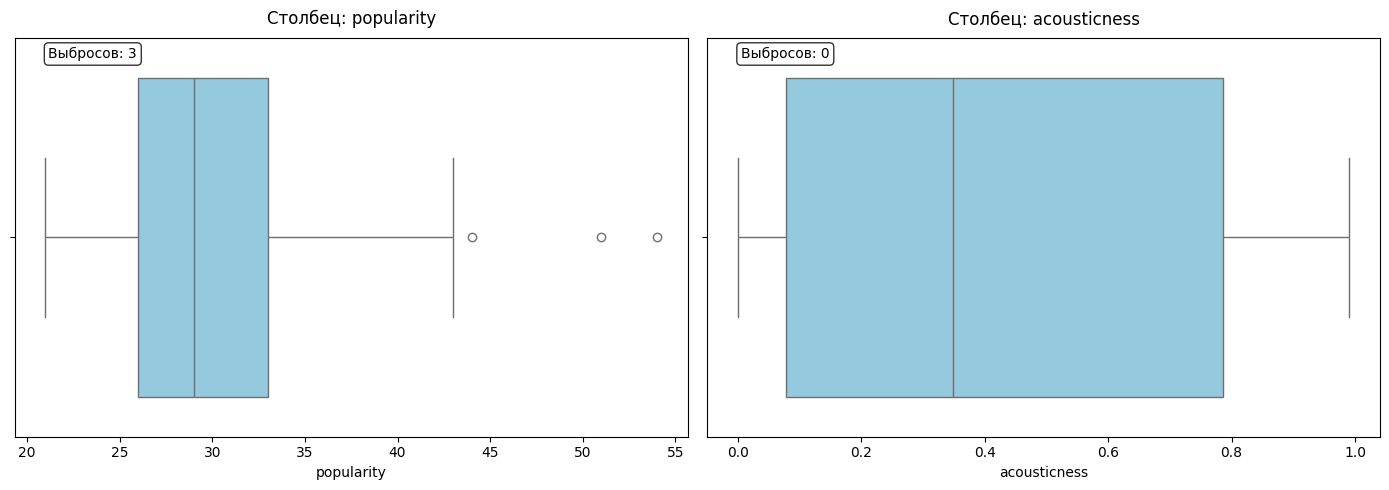

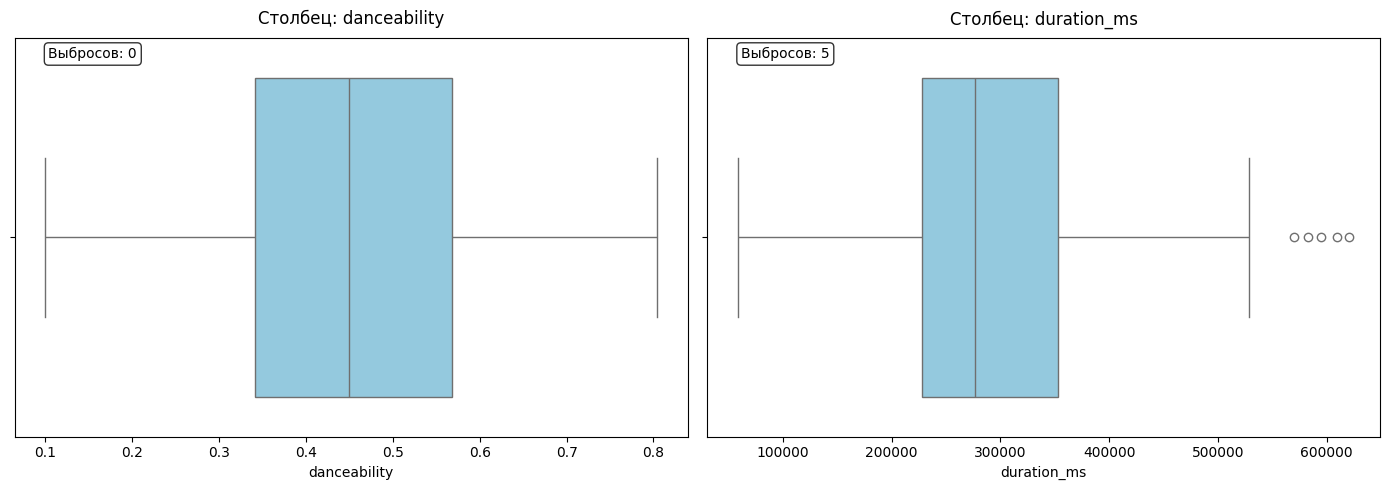

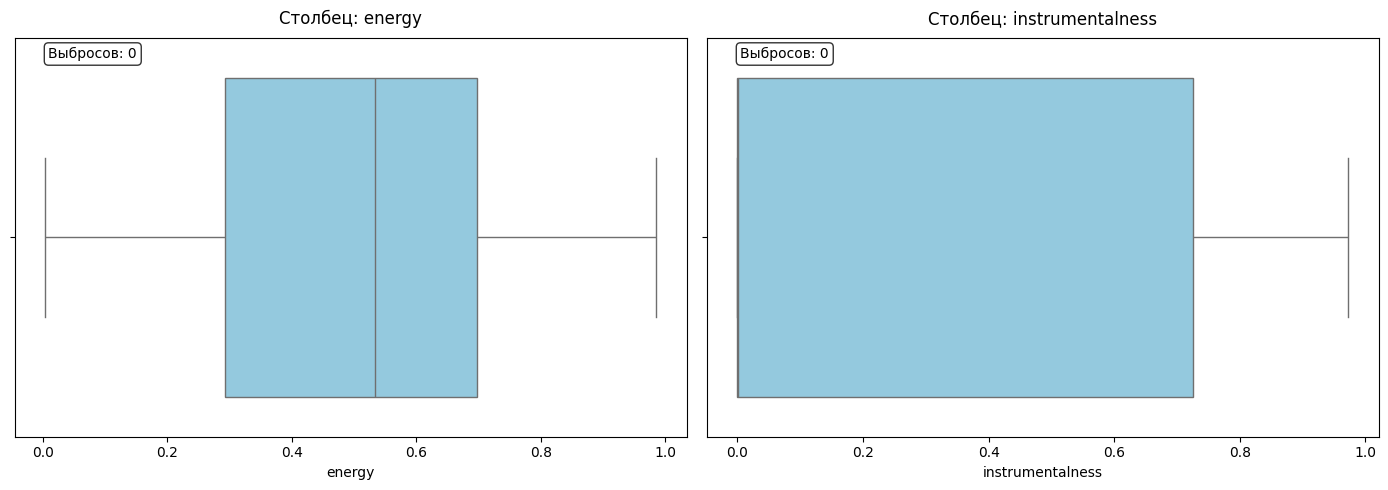

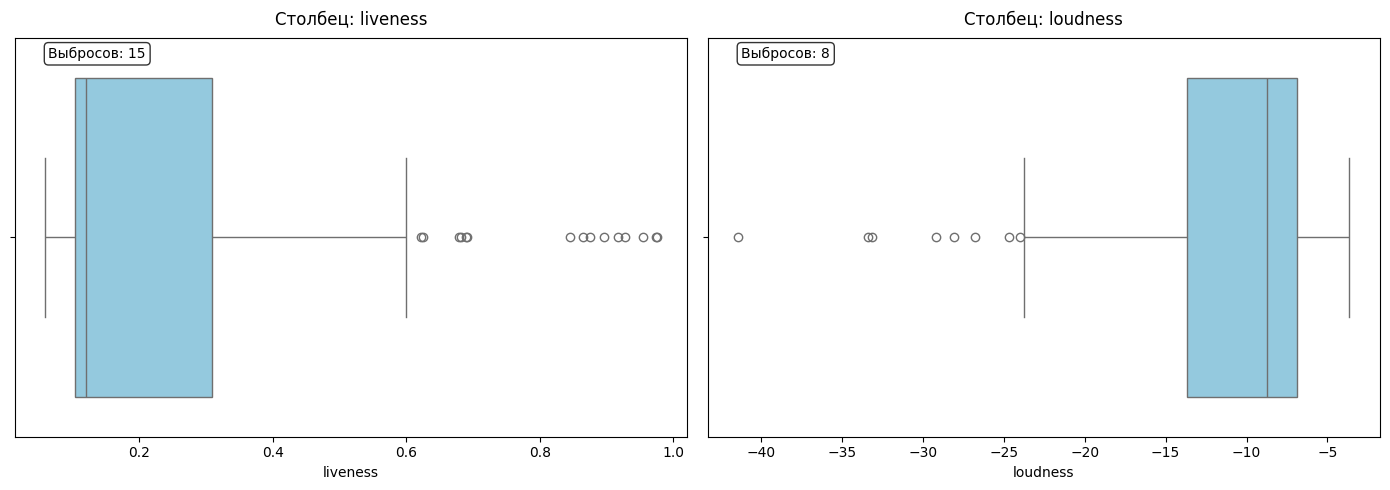

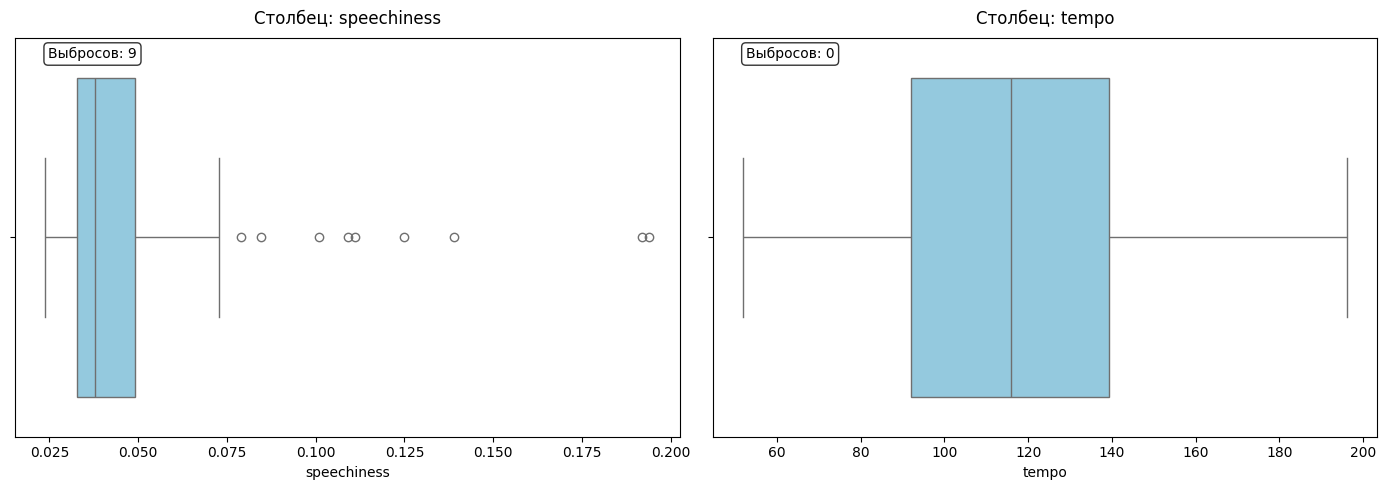

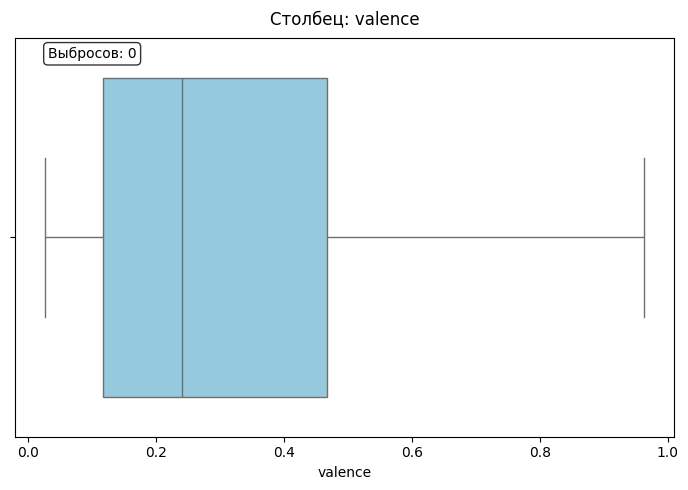

,Столбец,Выбросов,Границы
0,popularity,3,"[15.50, 43.50]"
1,acousticness,0,"[-0.98, 1.85]"
2,danceability,0,"[0.00, 0.91]"
3,duration_ms,5,"[39840.50, 541172.50]"
4,energy,0,"[-0.32, 1.30]"
5,instrumentalness,0,"[-1.09, 1.81]"
6,liveness,15,"[-0.20, 0.62]"
7,loudness,8,"[-23.89, 3.34]"
8,speechiness,9,"[0.01, 0.07]"
9,tempo,0,"[20.98, 210.14]"


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

df['duration_ms'] = pd.to_numeric(df['duration_ms'], errors='coerce')
df_filtered = df[(df['duration_ms'] > 0) & (df['duration_ms'] <= 3600000)].copy()
print("Данные duration_ms после фильтрации:")
print(df_filtered['duration_ms'].describe())
numeric_cols = df_filtered.select_dtypes(include=np.number).columns
print("Анализируемые столбцы:", numeric_cols)
outliers_stats = []
for i, column in enumerate(numeric_cols):
    if i % 2 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5)) if i + 1 < len(numeric_cols) else plt.subplots(1, 1, figsize=(7, 5))
        axes = [axes] if not isinstance(axes, np.ndarray) else axes

    sns.boxplot(x=df_filtered[column], ax=axes[i % 2], color='skyblue')
    axes[i % 2].set_title(f'Столбец: {column}', pad=10)

    Q1 = df_filtered[column].quantile(0.25)
    Q3 = df_filtered[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_filtered[(df_filtered[column] < lower) | (df_filtered[column] > upper)][column]

    axes[i % 2].annotate(f'Выбросов: {len(outliers)}', xy=(0.05, 0.95),
                        xycoords='axes fraction', fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    outliers_stats.append({
        'Столбец': column,
        'Выбросов': len(outliers),
        'Границы': f"[{lower:.2f}, {upper:.2f}]"
    })

    if (i + 1) % 2 == 0 or i == len(numeric_cols) - 1:
        plt.tight_layout()
        plt.show()

display(pd.DataFrame(outliers_stats))

In [ ]:
def auto_clean_dataframe(df, protected_columns=['track_id', 'track_name', 'artist_name', 'genre']):

    report = {
        'original_rows': len(df),
        'duplicates_removed': 0,
        'na_fixed': {},
        'outliers_removed': 0,
        'invalid_values_replaced': 0,
        'na_rows_removed': 0,
        'final_rows': len(df)
    }
    df_clean = df.copy()
    before = len(df_clean)
    cols_to_check = [col for col in df_clean.columns if col not in protected_columns]
    df_clean = df_clean.drop_duplicates(subset=cols_to_check)
    report['duplicates_removed'] = before - len(df_clean)
    for col in df_clean.columns:
        if col in protected_columns:
            continue
        report['na_fixed'][col] = {
            'before': df_clean[col].isna().sum(),
            'after': 0
        }
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            if df_clean[col].nunique() > 10:
                Q1 = df_clean[col].quantile(0.25)
                Q3 = df_clean[col].quantile(0.75)
                IQR = Q3 - Q1
                mask = (df_clean[col] >= (Q1 - 1.5*IQR)) & (df_clean[col] <= (Q3 + 1.5*IQR))
                report['outliers_removed'] += len(df_clean) - mask.sum()
                df_clean = df_clean[mask]
        else:
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'unknown'
            df_clean[col] = df_clean[col].fillna(mode_val)
            df_clean[col] = df_clean[col].astype(str).str.strip()
            invalid_values = ['', 'nan', 'NaN', 'None', 'null', 'NULL', '?', '-', 'NA']
            mask = df_clean[col].isin(invalid_values)
            report['invalid_values_replaced'] += mask.sum()
            df_clean.loc[mask, col] = 'unknown'
        report['na_fixed'][col]['after'] = df_clean[col].isna().sum()
    before = len(df_clean)
    cols_to_check = [col for col in df_clean.columns if col not in protected_columns]
    df_clean = df_clean.dropna(subset=cols_to_check)
    report['na_rows_removed'] = before - len(df_clean)
    report['final_rows'] = len(df_clean)

    return df_clean, report

def print_cleaning_report(report):
    print(f"Исходное количество строк: {report['original_rows']}")
    print(f"Удалено дубликатов: {report['duplicates_removed']}")
    print(f"Удалено строк с выбросами: {report['outliers_removed']}")
    print(f"Удалено строк с пропусками: {report['na_rows_removed']}")
    print(f"Заменено некорректных значений: {report['invalid_values_replaced']}")
    print(f"\nИтоговое количество строк: {report['final_rows']}")

cleaned_df, report = auto_clean_dataframe(df)
print_cleaning_report(report)

Исходное количество строк: 101
Удалено дубликатов: 0
Удалено строк с выбросами: 32
Удалено строк с пропусками: 0
Заменено некорректных значений: 0

Итоговое количество строк: 69


In [ ]:
def auto_clean_dataframe(df, iqr_multiplier=1.5, replace_with_median=True,
                        protected_columns=['track_id', 'track_name', 'artist_name', 'genre']):
    report = {
        'original_rows': len(df),
        'duplicates_removed': 0,
        'na_fixed': {},
        'outliers_replaced': 0,
        'invalid_values_replaced': 0,
        'na_rows_removed': 0,
        'final_rows': len(df)
    }
    df_clean = df.copy()
    before = len(df_clean)
    cols_to_check = [col for col in df_clean.columns if col not in protected_columns]
    df_clean = df_clean.drop_duplicates(subset=cols_to_check)
    report['duplicates_removed'] = before - len(df_clean)
    for col in df_clean.columns:
        if col in protected_columns:
            continue
        report['na_fixed'][col] = {
            'before': df_clean[col].isna().sum(),
            'after': 0
        }

        if pd.api.types.is_numeric_dtype(df_clean[col]):
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            if df_clean[col].nunique() > 10:
                Q1 = df_clean[col].quantile(0.25)
                Q3 = df_clean[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - iqr_multiplier * IQR
                upper_bound = Q3 + iqr_multiplier * IQR

                if replace_with_median:
                    mask_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
                    report['outliers_replaced'] += mask_outliers.sum()
                    df_clean.loc[mask_outliers, col] = median_val
                else:
                    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
        else:
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'unknown'
            df_clean[col] = df_clean[col].fillna(mode_val)
            df_clean[col] = df_clean[col].astype(str).str.strip()
            invalid_values = ['', 'nan', 'NaN', 'None', 'null', 'NULL', '?', '-', 'NA']
            mask = df_clean[col].isin(invalid_values)
            report['invalid_values_replaced'] += mask.sum()
            df_clean.loc[mask, col] = 'unknown'

        report['na_fixed'][col]['after'] = df_clean[col].isna().sum()
    before = len(df_clean)
    cols_to_check = [col for col in df_clean.columns if col not in protected_columns]
    df_clean = df_clean.dropna(subset=cols_to_check)
    report['na_rows_removed'] = before - len(df_clean)
    report['final_rows'] = len(df_clean)

    return df_clean, report

def print_cleaning_report(report):
    """Выводит отчет об очистке данных"""
    print(f"Исходное количество строк: {report['original_rows']}")
    print(f"Удалено дубликатов: {report['duplicates_removed']}")
    print(f"Заменено выбросов: {report['outliers_replaced']}")
    print(f"Удалено строк с пропусками: {report['na_rows_removed']}")
    print(f"Заменено некорректных значений: {report['invalid_values_replaced']}")
    print(f"\nИтоговое количество строк: {report['final_rows']}")

protected_cols = ['track_id', 'track_name', 'artist_name', 'genre']
cleaned_df, report = auto_clean_dataframe(df, iqr_multiplier=1.5,
                                        replace_with_median=True,
                                        protected_columns=protected_cols)
print_cleaning_report(report)


Исходное количество строк: 101
Удалено дубликатов: 0
Заменено выбросов: 40
Удалено строк с пропусками: 0
Заменено некорректных значений: 0

Итоговое количество строк: 101


In [ ]:
df = cleaned_df

Shapiro-Wilk test p-value: 0.0000


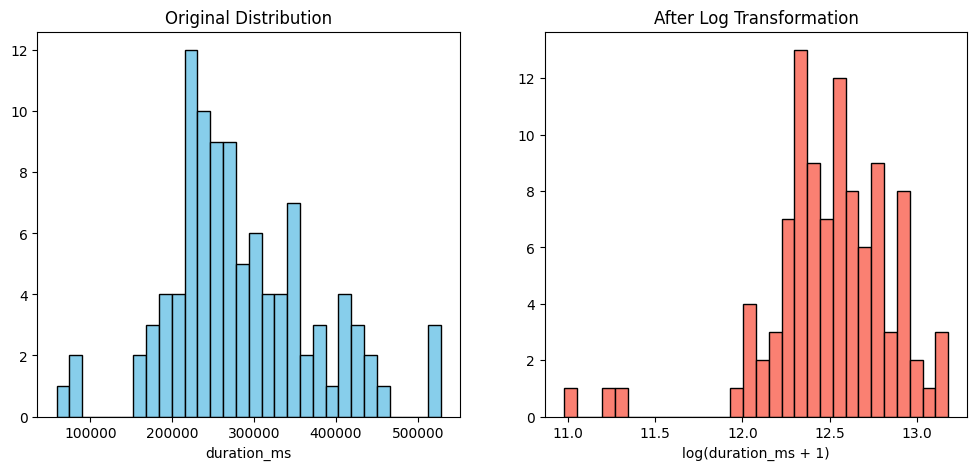

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df['duration_ms'] = pd.to_numeric(df['duration_ms'], errors='coerce')
duration_log = np.log1p(df['duration_ms'])
shapiro_test = stats.shapiro(duration_log)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['duration_ms'], bins=30, color='skyblue', edgecolor='black')
plt.title('Original Distribution')
plt.xlabel('duration_ms')

plt.subplot(1, 2, 2)
plt.hist(duration_log, bins=30, color='salmon', edgecolor='black')
plt.title('After Log Transformation')
plt.xlabel('log(duration_ms + 1)')
plt.show()
df['duration_ms'] = duration_log

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_numeric_columns(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    if not numeric_cols:
        print("В DataFrame нет числовых столбцов для анализа")
        return

    stats_data = {
        'Показатель': ['Среднее', 'Медиана', 'Мода', 'Дисперсия', 'Стандартное отклонение',
                      'Минимум', '25% перцентиль', '75% перцентиль', 'Максимум']
    }

    for col in numeric_cols:
        stats_data[col] = [
            df[col].mean(),
            df[col].median(),
            df[col].mode()[0] if not df[col].mode().empty else np.nan,
            df[col].var(),
            df[col].std(),
            df[col].min(),
            df[col].quantile(0.25),
            df[col].quantile(0.75),
            df[col].max()
        ]

    stats_df = pd.DataFrame(stats_data)

    cov_matrix = df[numeric_cols].cov()
    corr_matrix = df[numeric_cols].corr()


    print("Основные статистические показатели:")
    display(stats_df)

    print("\nМатрица ковариации:")
    display(cov_matrix)

    print("\nМатрица корреляции:")
    display(corr_matrix)

    plt.show()
analyze_numeric_columns(df)

Основные статистические показатели:


,Показатель,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
0,Среднее,30.000000,0.427795,0.452109,12.545532,0.498052,0.290046,0.255674,-11.634485,0.047334,117.212901,0.312549
1,Медиана,29.000000,0.349000,0.450000,12.530295,0.533000,0.001620,0.120000,-8.746000,0.037900,115.995000,0.240000
2,Мода,28.000000,0.932000,0.415000,10.978285,0.292000,0.000000,0.108000,-41.409000,0.030000,115.995000,0.039200
3,Дисперсия,38.060000,0.131517,0.028485,0.158021,0.071319,0.145924,0.069644,52.035329,0.000855,945.304008,0.055144
4,Стандартное отклонение,6.169279,0.362653,0.168776,0.397519,0.267056,0.382000,0.263902,7.213552,0.029233,30.745797,0.234828
5,Минимум,21.000000,0.000300,0.100000,10.978285,0.003960,0.000000,0.059800,-41.409000,0.023800,51.857000,0.025700
6,25% перцентиль,26.000000,0.077800,0.341000,12.336403,0.292000,0.000002,0.104000,-13.677000,0.032700,91.915000,0.116000
7,75% перцентиль,33.000000,0.786000,0.568000,12.774716,0.697000,0.726000,0.309000,-6.871000,0.049100,139.207000,0.467000
8,Максимум,54.000000,0.991000,0.804000,13.338995,0.986000,0.973000,0.975000,-3.640000,0.194000,196.160000,0.963000



Матрица ковариации:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity,38.060000,-0.001288,-0.055090,0.247531,-0.019736,0.016223,0.135474,0.495070,0.013682,-4.302970,-0.013722
acousticness,-0.001288,0.131517,-0.020996,-0.042154,-0.074518,0.062215,-0.030544,-1.599993,-0.000928,-3.646287,-0.016026
danceability,-0.055090,-0.020996,0.028485,-0.006313,0.020119,-0.015168,-0.000339,0.523254,0.000588,0.810296,0.025709
duration_ms,0.247531,-0.042154,-0.006313,0.158021,0.023033,-0.014755,0.001281,0.773368,-0.002068,-0.655020,-0.027251
energy,-0.019736,-0.074518,0.020119,0.023033,0.071319,-0.054789,0.029476,1.538565,0.001939,2.264126,0.028048
instrumentalness,0.016223,0.062215,-0.015168,-0.014755,-0.054789,0.145924,-0.028596,-1.949158,-0.001072,-1.126588,-0.019739
liveness,0.135474,-0.030544,-0.000339,0.001281,0.029476,-0.028596,0.069644,0.588478,0.003409,0.414799,0.011204
loudness,0.495070,-1.599993,0.523254,0.773368,1.538565,-1.949158,0.588478,52.035329,0.012268,39.761306,0.576399
speechiness,0.013682,-0.000928,0.000588,-0.002068,0.001939,-0.001072,0.003409,0.012268,0.000855,0.039950,0.002461
tempo,-4.302970,-3.646287,0.810296,-0.655020,2.264126,-1.126588,0.414799,39.761306,0.039950,945.304008,0.064888



Матрица корреляции:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity,1.000000,-0.000576,-0.052909,0.100934,-0.011979,0.006884,0.083211,0.011125,0.075864,-0.022685,-0.009472
acousticness,-0.000576,1.000000,-0.343039,-0.292406,-0.769426,0.449097,-0.319153,-0.611615,-0.087498,-0.327020,-0.188190
danceability,-0.052909,-0.343039,1.000000,-0.094099,0.446365,-0.235260,-0.007611,0.429785,0.119190,0.156152,0.648680
duration_ms,0.100934,-0.292406,-0.094099,1.000000,0.216969,-0.097164,0.012207,0.269699,-0.177996,-0.053593,-0.291929
energy,-0.011979,-0.769426,0.446365,0.216969,1.000000,-0.537070,0.418246,0.798665,0.248336,0.275748,0.447255
instrumentalness,0.006884,0.449097,-0.235260,-0.097164,-0.537070,1.000000,-0.283661,-0.707350,-0.096028,-0.095921,-0.220046
liveness,0.083211,-0.319153,-0.007611,0.012207,0.418246,-0.283661,1.000000,0.309128,0.441892,0.051122,0.180790
loudness,0.011125,-0.611615,0.429785,0.269699,0.798665,-0.707350,0.309128,1.000000,0.058174,0.179277,0.340270
speechiness,0.075864,-0.087498,0.119190,-0.177996,0.248336,-0.096028,0.441892,0.058174,1.000000,0.044448,0.358482
tempo,-0.022685,-0.327020,0.156152,-0.053593,0.275748,-0.095921,0.051122,0.179277,0.044448,1.000000,0.008987


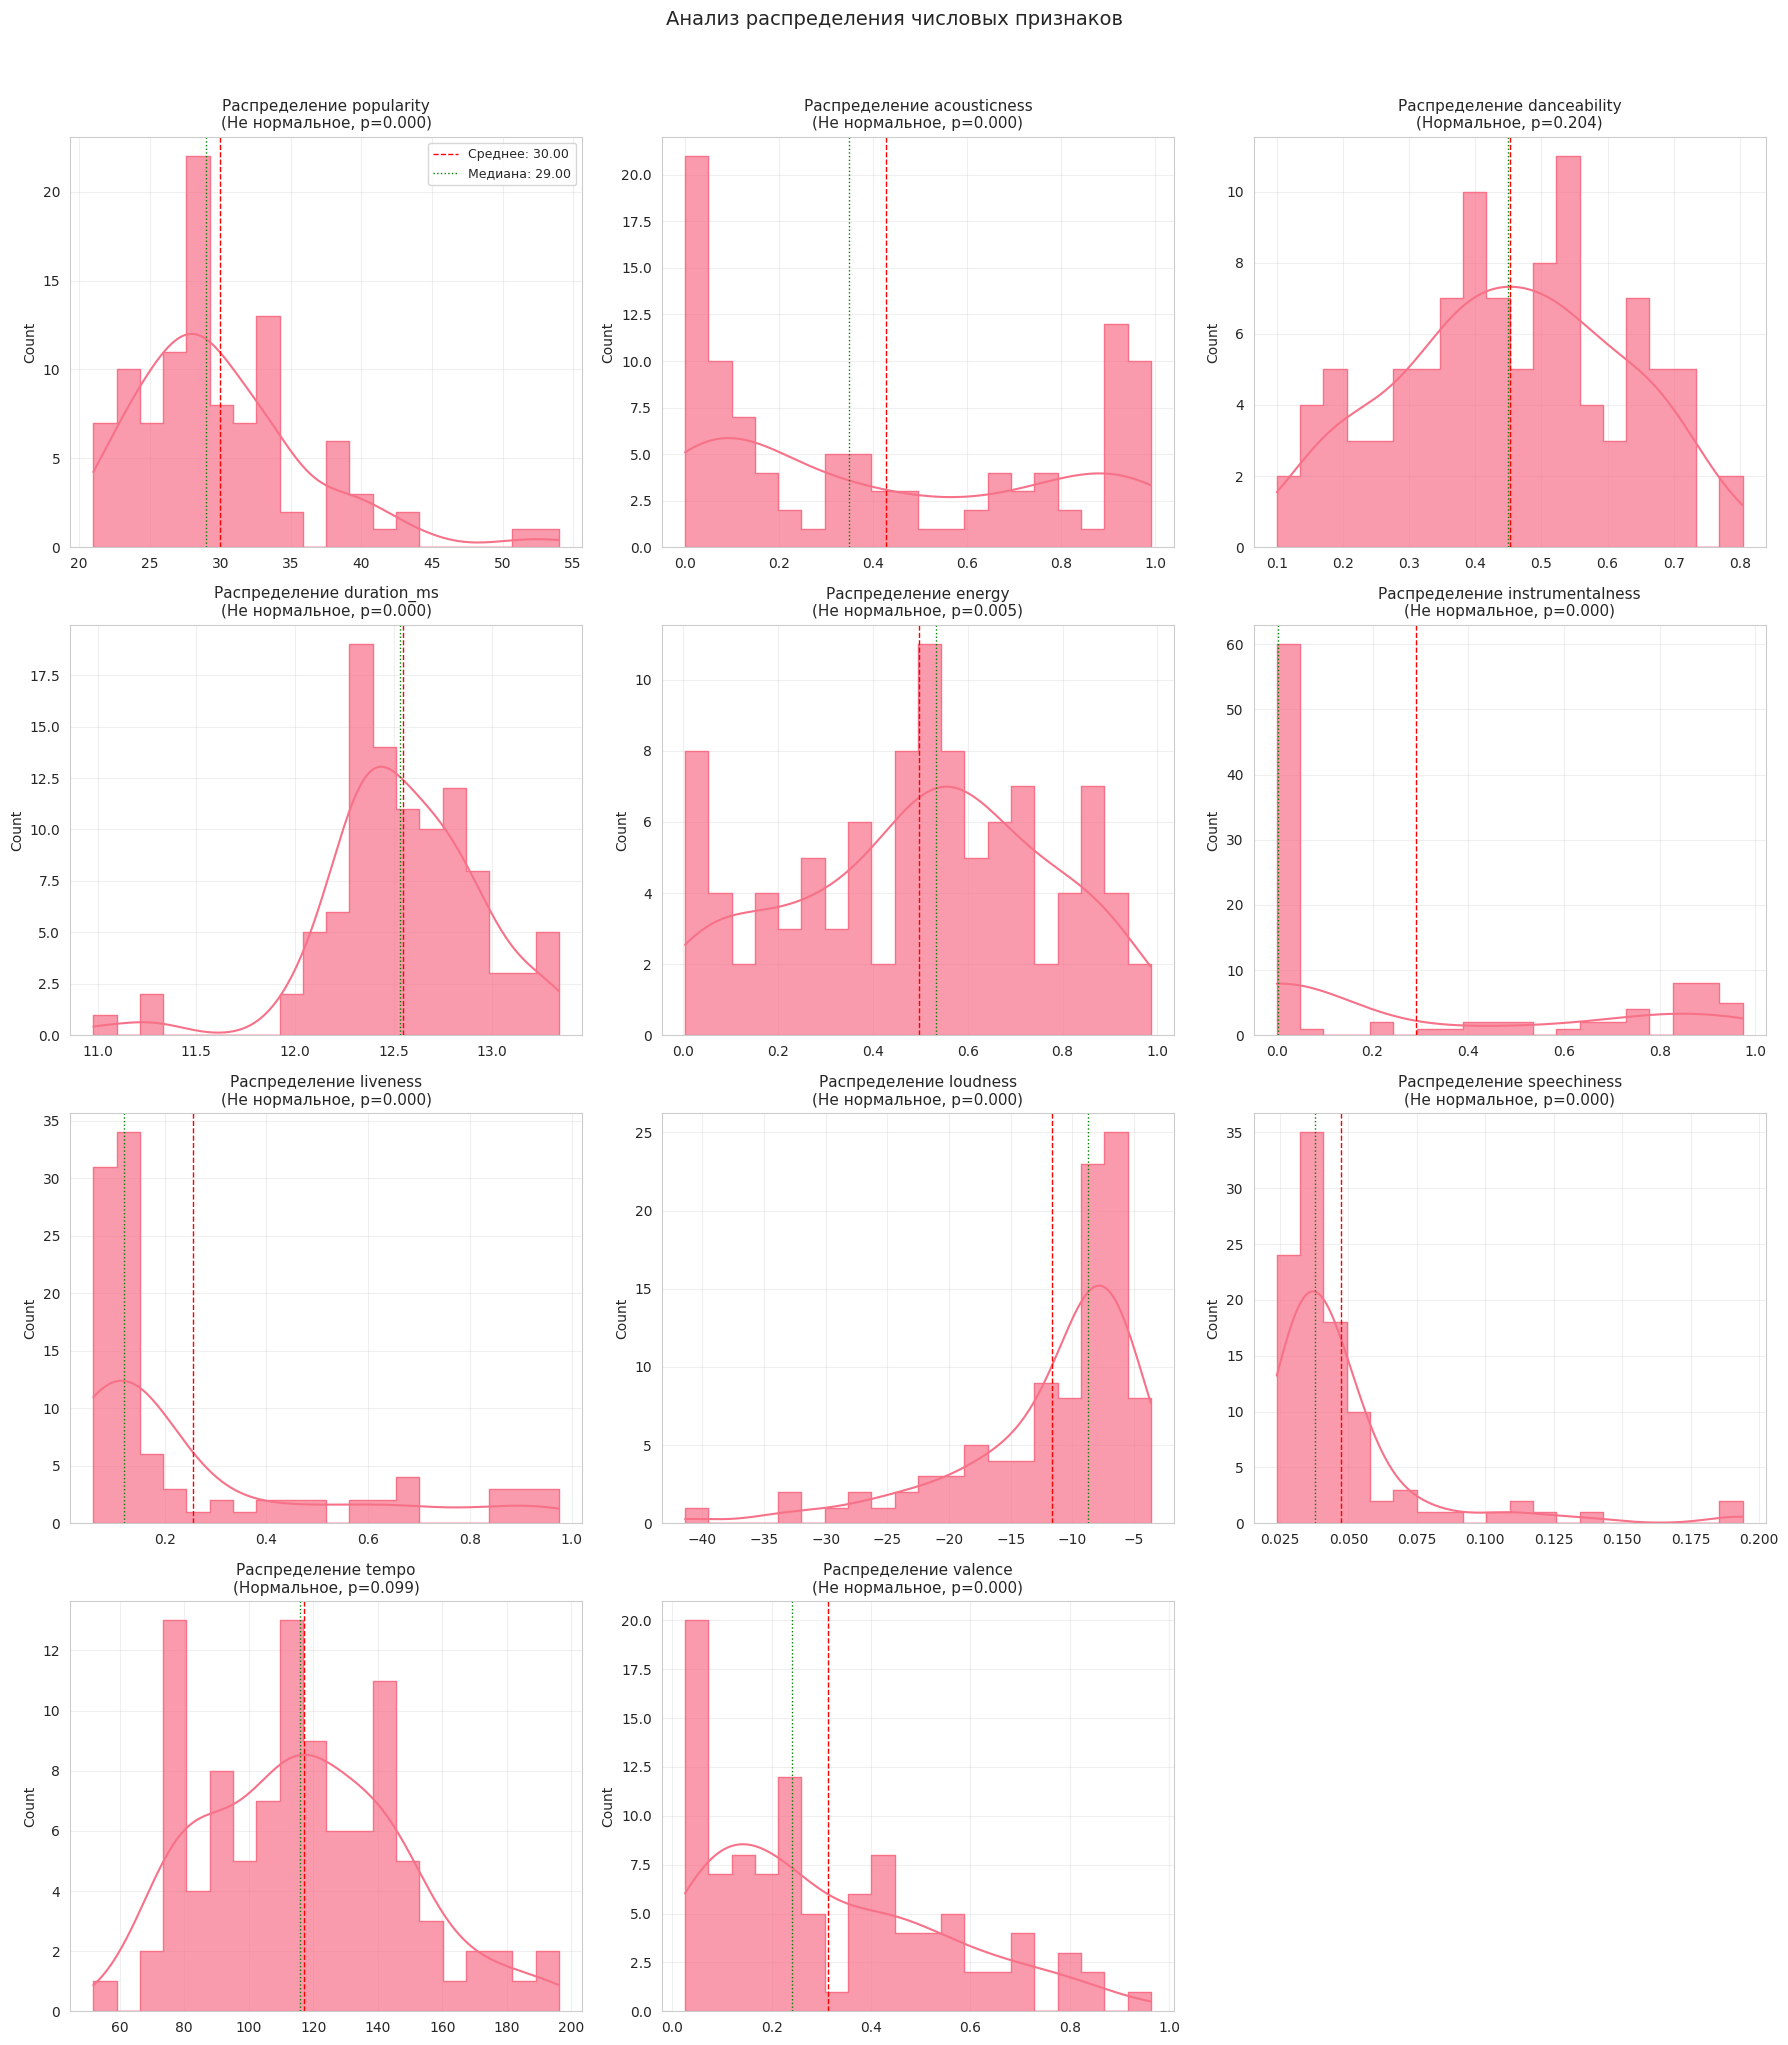

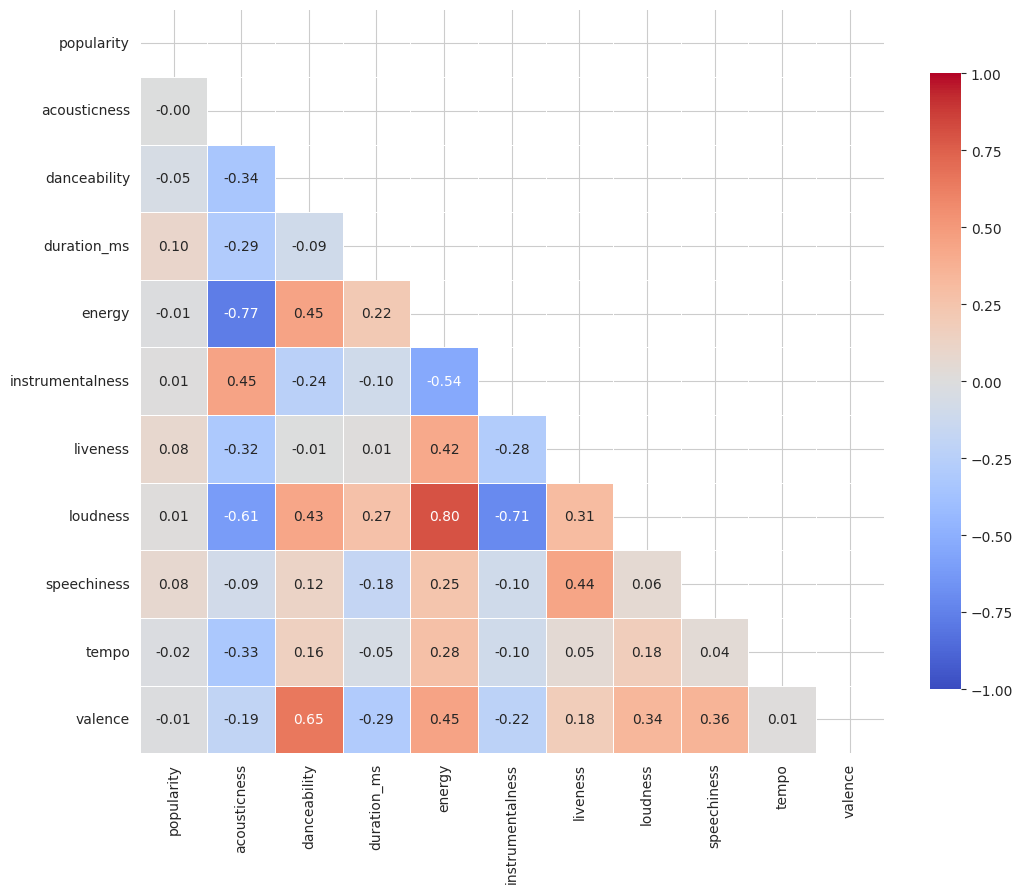

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

def analyze_numeric_features_with_corr_matrix(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if not numeric_cols:
        print("В DataFrame нет числовых столбцов для анализа")
        return
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    plt.rcParams['font.size'] = 10

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        sns.histplot(df[col], kde=True, bins=20, ax=ax, element="step", fill=True, alpha=0.7)

        mean_val = df[col].mean()
        median_val = df[col].median()

        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Среднее: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle=':', linewidth=1, label=f'Медиана: {median_val:.2f}')

        stat, p = stats.shapiro(df[col].dropna())
        norm_text = "Нормальное" if p > 0.05 else "Не нормальное"

        ax.set_title(f'Распределение {col}\n({norm_text}, p={p:.3f})', fontsize=11)
        ax.set_xlabel('')
        ax.grid(True, alpha=0.3)

        if idx == 0:
            ax.legend(fontsize=9)

    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Анализ распределения числовых признаков', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    if len(numeric_cols) > 1:
        plt.figure(figsize=(12, 10))

        corr_matrix = df[numeric_cols].corr()

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
                             cmap="coolwarm", vmin=-1, vmax=1, center=0,
                             square=True, linewidths=.5, cbar_kws={"shrink": .8})

analyze_numeric_features_with_corr_matrix(df)

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import ttest_ind, ttest_rel, f_oneway
from itertools import combinations

def calculate_correlations(df, numeric_cols=None):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    print("Матрица корреляций Пирсона:")
    pearson_corr = df[numeric_cols].corr(method='pearson')
    display(pearson_corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))

    print("\nМатрица корреляций Спирмена:")
    spearman_corr = df[numeric_cols].corr(method='spearman')
    display(spearman_corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))

    return pearson_corr, spearman_corr

def compare_groups_for_all_numeric(df, group_col, paired=False, alpha=0.05):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    groups = df[group_col].unique()

    if len(groups) != 2:
        raise ValueError("Функция работает только для сравнения 2 групп")

    results = []
    for col in numeric_cols:
        group1 = df[df[group_col] == groups[0]][col]
        group2 = df[df[group_col] == groups[1]][col]

        if paired:
            t_stat, p_value = ttest_rel(group1, group2)
            test_type = "парный t-тест"
        else:
            t_stat, p_value = ttest_ind(group1, group2)
            test_type = "независимый t-тест"

        is_significant = p_value < alpha
        results.append({
            'Переменная': col,
            'Тест': test_type,
            'Группа 1': groups[0],
            'Группа 2': groups[1],
            't-статистика': t_stat,
            'p-value': p_value,
            'Значимость': 'Да' if is_significant else 'Нет'
        })

    results_df = pd.DataFrame(results)
    print(f"\nРезультаты сравнения групп '{groups[0]}' и '{groups[1]}' для всех числовых столбцов:")
    display(results_df)

    return results_df

def compare_variances_for_all_numeric(df, group_col, alpha=0.05):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    groups = df[group_col].unique()

    if len(groups) != 2:
        raise ValueError("Функция работает только для сравнения 2 групп")

    results = []
    for col in numeric_cols:
        group1 = df[df[group_col] == groups[0]][col]
        group2 = df[df[group_col] == groups[1]][col]

        f_stat = np.var(group1, ddof=1) / np.var(group2, ddof=1)
        df1 = len(group1) - 1
        df2 = len(group2) - 1
        p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

        is_significant = p_value < alpha
        results.append({
            'Переменная': col,
            'Группа 1': groups[0],
            'Группа 2': groups[1],
            'F-статистика': f_stat,
            'p-value': p_value,
            'Значимость': 'Да' if is_significant else 'Нет'
        })

    results_df = pd.DataFrame(results)
    print(f"\nРезультаты сравнения дисперсий для групп '{groups[0]}' и '{groups[1]}':")
    display(results_df)

    return results_df

def anova_for_all_numeric(df, group_col, alpha=0.05):
    """
    Односторонний ANOVA для всех числовых столбцов
    """
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    groups = df[group_col].unique()

    if len(groups) < 2:
        raise ValueError("Для ANOVA требуется как минимум 2 группы")

    results = []
    for col in numeric_cols:
        group_data = [df[df[group_col] == g][col] for g in groups]
        f_stat, p_value = f_oneway(*group_data)

        is_significant = p_value < alpha
        results.append({
            'Переменная': col,
            'F-статистика': f_stat,
            'p-value': p_value,
            'Значимость': 'Да' if is_significant else 'Нет'
        })

    results_df = pd.DataFrame(results)
    print(f"\nРезультаты ANOVA для всех числовых столбцов по группировке '{group_col}':")
    display(results_df)

    return results_df

if __name__ == "__main__":
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    print("Числовые столбцы в данных:", numeric_cols)
    pearson_corr, spearman_corr = calculate_correlations(df)
    if 'genre' in df.columns and len(df['genre'].unique()) == 2:
        ttest_results = compare_groups_for_all_numeric(df, 'genre')
        variance_results = compare_variances_for_all_numeric(df, 'genre')
    elif 'genre' in df.columns:
        print("\nДля столбца 'genre' обнаружено", len(df['genre'].unique()), "групп. Выполняем ANOVA:")
        anova_results = anova_for_all_numeric(df, 'genre')
    else:
        print("\nСтолбец 'genre' не найден или содержит недостаточно групп для сравнения")

Числовые столбцы в данных: ['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
Матрица корреляций Пирсона:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity,1.000000,-0.000576,-0.052909,0.100934,-0.011979,0.006884,0.083211,0.011125,0.075864,-0.022685,-0.009472
acousticness,-0.000576,1.000000,-0.343039,-0.292406,-0.769426,0.449097,-0.319153,-0.611615,-0.087498,-0.327020,-0.188190
danceability,-0.052909,-0.343039,1.000000,-0.094099,0.446365,-0.235260,-0.007611,0.429785,0.119190,0.156152,0.648680
duration_ms,0.100934,-0.292406,-0.094099,1.000000,0.216969,-0.097164,0.012207,0.269699,-0.177996,-0.053593,-0.291929
energy,-0.011979,-0.769426,0.446365,0.216969,1.000000,-0.537070,0.418246,0.798665,0.248336,0.275748,0.447255
instrumentalness,0.006884,0.449097,-0.235260,-0.097164,-0.537070,1.000000,-0.283661,-0.707350,-0.096028,-0.095921,-0.220046
liveness,0.083211,-0.319153,-0.007611,0.012207,0.418246,-0.283661,1.000000,0.309128,0.441892,0.051122,0.180790
loudness,0.011125,-0.611615,0.429785,0.269699,0.798665,-0.707350,0.309128,1.000000,0.058174,0.179277,0.340270
speechiness,0.075864,-0.087498,0.119190,-0.177996,0.248336,-0.096028,0.441892,0.058174,1.000000,0.044448,0.358482
tempo,-0.022685,-0.327020,0.156152,-0.053593,0.275748,-0.095921,0.051122,0.179277,0.044448,1.000000,0.008987



Матрица корреляций Спирмена:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity,1.000000,0.055828,-0.066555,0.104645,-0.096062,0.120693,-0.085602,-0.060309,0.031522,-0.107043,-0.038474
acousticness,0.055828,1.000000,-0.301291,-0.301946,-0.758731,0.350184,-0.324433,-0.592196,-0.072426,-0.353206,-0.250448
danceability,-0.066555,-0.301291,1.000000,-0.048511,0.381900,-0.069032,0.044991,0.247222,0.073063,0.130080,0.682944
duration_ms,0.104645,-0.301946,-0.048511,1.000000,0.226159,-0.139124,0.087718,0.268620,-0.097790,-0.000181,-0.190224
energy,-0.096062,-0.758731,0.381900,0.226159,1.000000,-0.439441,0.377715,0.804030,0.291309,0.288485,0.479755
instrumentalness,0.120693,0.350184,-0.069032,-0.139124,-0.439441,1.000000,-0.240947,-0.720003,0.053117,-0.104720,-0.207370
liveness,-0.085602,-0.324433,0.044991,0.087718,0.377715,-0.240947,1.000000,0.387958,0.185591,0.095873,0.223592
loudness,-0.060309,-0.592196,0.247222,0.268620,0.804030,-0.720003,0.387958,1.000000,0.054777,0.150006,0.351182
speechiness,0.031522,-0.072426,0.073063,-0.097790,0.291309,0.053117,0.185591,0.054777,1.000000,0.159062,0.231848
tempo,-0.107043,-0.353206,0.130080,-0.000181,0.288485,-0.104720,0.095873,0.150006,0.159062,1.000000,0.053618



Для столбца 'genre' обнаружено 1 групп. Выполняем ANOVA:


ValueError: Для ANOVA требуется как минимум 2 группы

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, f

df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

df_filtered = df.dropna(subset=['popularity', 'energy'])

median_value = np.median(df_filtered['energy'])

group_lower = df_filtered['popularity'][df_filtered['energy'] < median_value]
group_upper = df_filtered['popularity'][df_filtered['energy'] > median_value]

print(f"Медиана: {median_value:.4f}")
print(f"Группа ниже медианы: {len(group_lower)} наблюдений")
print(f"Группа выше медианы: {len(group_upper)} наблюдений")

if len(group_lower) == 0 or len(group_upper) == 0:
    print("Одна из групп пустая – проведение t-теста невозможно.")
else:
    t_stat, p_value_t = ttest_ind(group_lower, group_upper, equal_var=False)
    print("\nНезависимый t-тест между группами по переменной 'energy':")
    print(f"t-статистика: {t_stat:.4f}")
    print(f"p-значение: {p_value_t:.4f}")

var_lower = np.var(group_lower, ddof=1)
var_upper = np.var(group_upper, ddof=1)

if var_lower > var_upper:
    F_statistic = var_lower / var_upper
    dfn = len(group_lower) - 1
    dfd = len(group_upper) - 1
else:
    F_statistic = var_upper / var_lower
    dfn = len(group_upper) - 1
    dfd = len(group_lower) - 1

p_value_f = 1 - f.cdf(F_statistic, dfn, dfd)

print("\nF-тест на равенство дисперсий между группами по переменной 'energy':")
print(f"F-статистика: {F_statistic:.4f}")
print(f"p-значение: {p_value_f:.4f}")

Медиана: 0.5330
Группа ниже медианы: 50 наблюдений
Группа выше медианы: 49 наблюдений

Независимый t-тест между группами по переменной 'energy':
t-статистика: 0.0802
p-значение: 0.9363

F-тест на равенство дисперсий между группами по переменной 'energy':
F-статистика: 2.1951
p-значение: 0.0035


Анализ распределения столбца 'popularity' (n=101)

Описательная статистика:
count    101.000000
mean      30.000000
std        6.169279
min       21.000000
25%       26.000000
50%       29.000000
75%       33.000000
max       54.000000
Name: popularity, dtype: float64

Дополнительные характеристики:
Коэффициент асимметрии: 1.2345
Коэффициент эксцесса: 2.1642


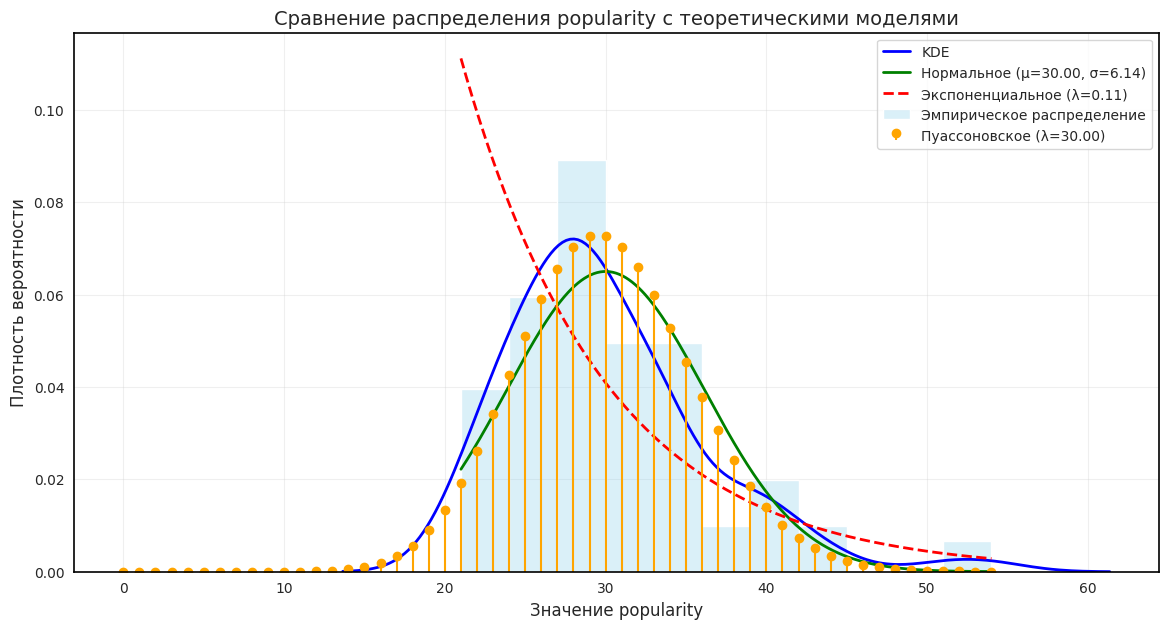

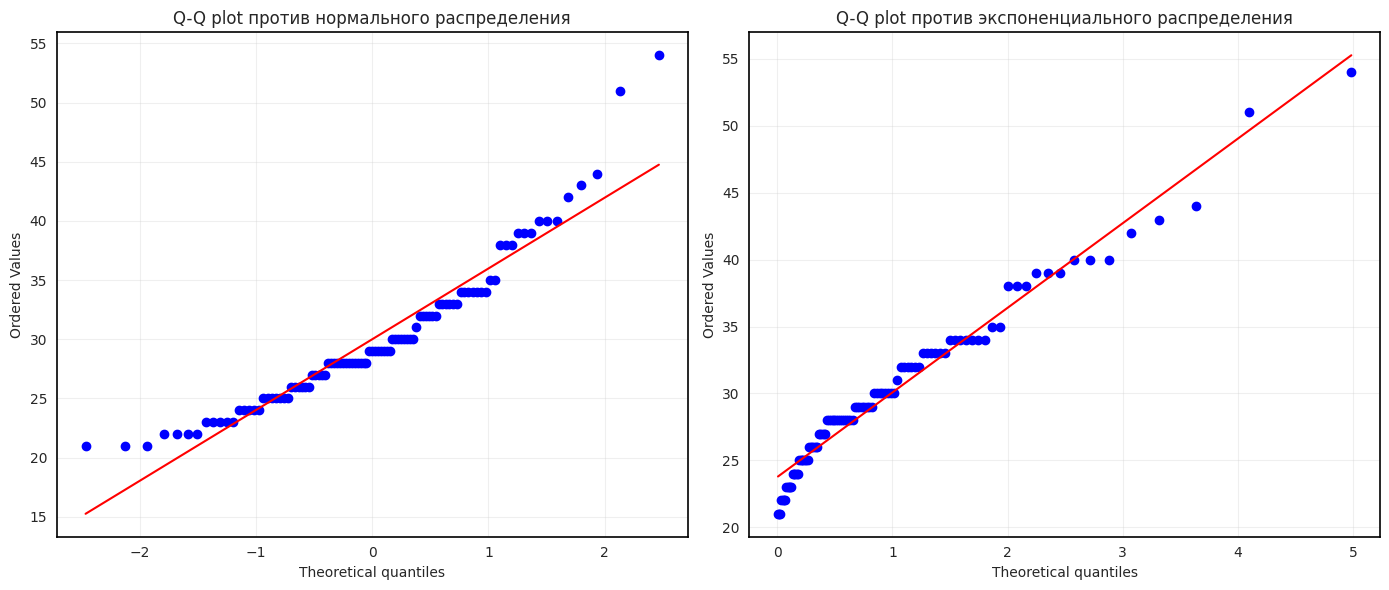

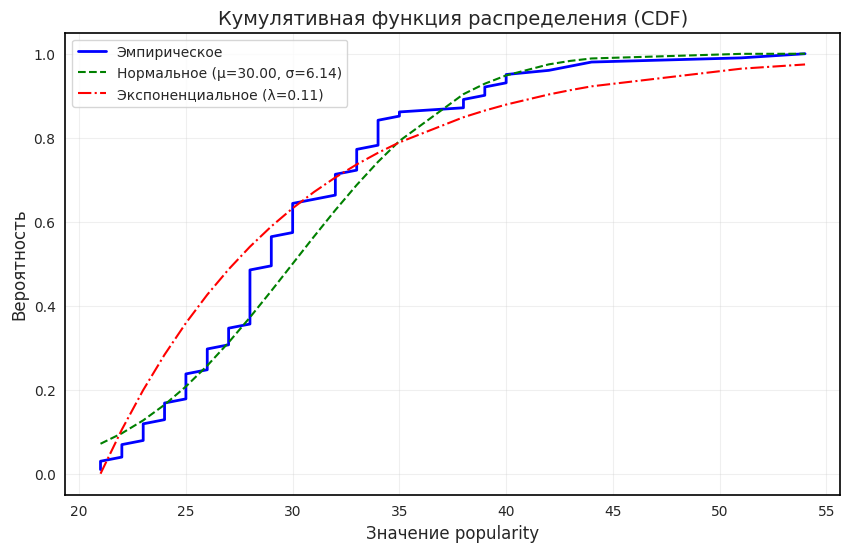


=== Проверка соответствия norm распределению ===
Критерий Колмогорова-Смирнова:
D = 0.1436, p-value = 0.0280

Критерий Шапиро-Уилка:
W = 0.9149, p-value = 0.0000

Вывод: Гипотеза отвергается (p ≤ 0.05)

=== Проверка соответствия expon распределению ===
Критерий Колмогорова-Смирнова:
D = 0.5034, p-value = 0.0000

Вывод: Гипотеза отвергается (p ≤ 0.05)

=== Проверка соответствия poisson распределению ===

Критерий хи-квадрат:
χ² = 12.8805, p-value = 0.1681

Вывод: Нет оснований отвергнуть гипотезу (p > 0.05)

Анализ завершен


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, expon, poisson

def fit_distributions(data, dist_names=['norm', 'expon', 'poisson']):
    plt.figure(figsize=(14, 7))
    sns.histplot(data, kde=False, stat='density', alpha=0.3,
                 color='skyblue', label='Эмпирическое распределение')
    sns.kdeplot(data, color='blue', linewidth=2, label='KDE')

    x = np.linspace(min(data), max(data), 500)
    if 'norm' in dist_names:
        mu, sigma = norm.fit(data)
        plt.plot(x, norm.pdf(x, mu, sigma), 'g-',
                label=f'Нормальное (μ={mu:.2f}, σ={sigma:.2f})', linewidth=2)
    if 'expon' in dist_names:
        loc, scale = expon.fit(data)
        plt.plot(x, expon.pdf(x, loc, scale), 'r--',
                label=f'Экспоненциальное (λ={1/scale:.2f})', linewidth=2)
    if 'poisson' in dist_names and all(data == data.astype(int)):
        mu = np.mean(data)
        x_vals = np.arange(0, int(max(data)) + 1)
        pmf = poisson.pmf(x_vals, mu)
        plt.stem(x_vals, pmf, label=f'Пуассоновское (λ={mu:.2f})',
                linefmt='orange', markerfmt='o', basefmt=' ')
    plt.title('Сравнение распределения popularity с теоретическими моделями', fontsize=14)
    plt.xlabel('Значение popularity', fontsize=12)
    plt.ylabel('Плотность вероятности', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_qq_plots(data):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    stats.probplot(data, dist='norm', plot=plt)
    plt.title('Q-Q plot против нормального распределения', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist='expon', plot=plt)
    plt.title('Q-Q plot против экспоненциального распределения', fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_cumulative_distribution(data):
    plt.figure(figsize=(10, 6))
    x = np.sort(data)
    y = np.arange(1, len(x)+1)/len(x)
    plt.plot(x, y, 'b-', linewidth=2, label='Эмпирическое')
    mu, sigma = norm.fit(data)
    plt.plot(x, norm.cdf(x, mu, sigma), 'g--',
             label=f'Нормальное (μ={mu:.2f}, σ={sigma:.2f})')
    loc, scale = expon.fit(data)
    plt.plot(x, expon.cdf(x, loc, scale), 'r-.',
             label=f'Экспоненциальное (λ={1/scale:.2f})')

    plt.title('Кумулятивная функция распределения (CDF)', fontsize=14)
    plt.xlabel('Значение popularity', fontsize=12)
    plt.ylabel('Вероятность', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

def test_distribution_fit(data, dist_type='norm'):
    print(f"\n=== Проверка соответствия {dist_type} распределению ===")
    try:
        if dist_type == 'norm':
            ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
            print(f"Критерий Колмогорова-Смирнова:\nD = {ks_stat:.4f}, p-value = {ks_p:.4f}")
            if len(data) < 5000:
                sh_stat, sh_p = stats.shapiro(data)
                print(f"\nКритерий Шапиро-Уилка:\nW = {sh_stat:.4f}, p-value = {sh_p:.4f}")

        elif dist_type == 'expon':
            ks_stat, ks_p = stats.kstest(data, 'expon', args=(0, np.mean(data)))
            print(f"Критерий Колмогорова-Смирнова:\nD = {ks_stat:.4f}, p-value = {ks_p:.4f}")

        elif dist_type == 'poisson' and all(data == data.astype(int)):
            hist = np.histogram(data, bins=np.arange(min(data)-0.5, max(data)+1.5))
            observed = hist[0]
            x_vals = hist[1][:-1] + 0.5
            expected = poisson.pmf(x_vals, np.mean(data)) * len(data)
            valid = expected >= 5
            if sum(valid) > 1:
                observed_valid = observed[valid]
                expected_valid = expected[valid]
                scaling_factor = np.sum(observed_valid) / np.sum(expected_valid)
                expected_valid = expected_valid * scaling_factor

                chi_stat, chi_p = stats.chisquare(observed_valid, expected_valid)
                print(f"\nКритерий хи-квадрат:\nχ² = {chi_stat:.4f}, p-value = {chi_p:.4f}")
                p_value = chi_p
            else:
                print("\nНедостаточно данных для теста хи-квадрат")
                return
        p_value = ks_p if 'ks_p' in locals() else chi_p if 'chi_p' in locals() else sh_p
        if p_value > 0.05:
            print("\nВывод: Нет оснований отвергнуть гипотезу (p > 0.05)")
        else:
            print("\nВывод: Гипотеза отвергается (p ≤ 0.05)")

    except Exception as e:
        print(f"\nОшибка при проверке: {str(e)}")

if __name__ == "__main__":
    data = df['popularity']

    if len(data) == 0:
        raise ValueError("Нет данных для анализа после удаления пропусков")

    print("="*50)
    print(f"Анализ распределения столбца 'popularity' (n={len(data)})")
    print("="*50)

    print("\nОписательная статистика:")
    print(data.describe())

    print("\nДополнительные характеристики:")
    print(f"Коэффициент асимметрии: {stats.skew(data):.4f}")
    print(f"Коэффициент эксцесса: {stats.kurtosis(data):.4f}")

    fit_distributions(data)
    plot_qq_plots(data)
    plot_cumulative_distribution(data)
    test_distribution_fit(data, 'norm')
    test_distribution_fit(data, 'expon')
    if all(data == data.astype(int)):
        test_distribution_fit(data, 'poisson')
    else:
        print("\nПримечание: Проверка распределения Пуассона не выполнена - данные не целочисленные")

    print("\nАнализ завершен")

ADF Statistic: -11.192990080463158
p-value: 2.3436653689049135e-20
Ряд стационарен


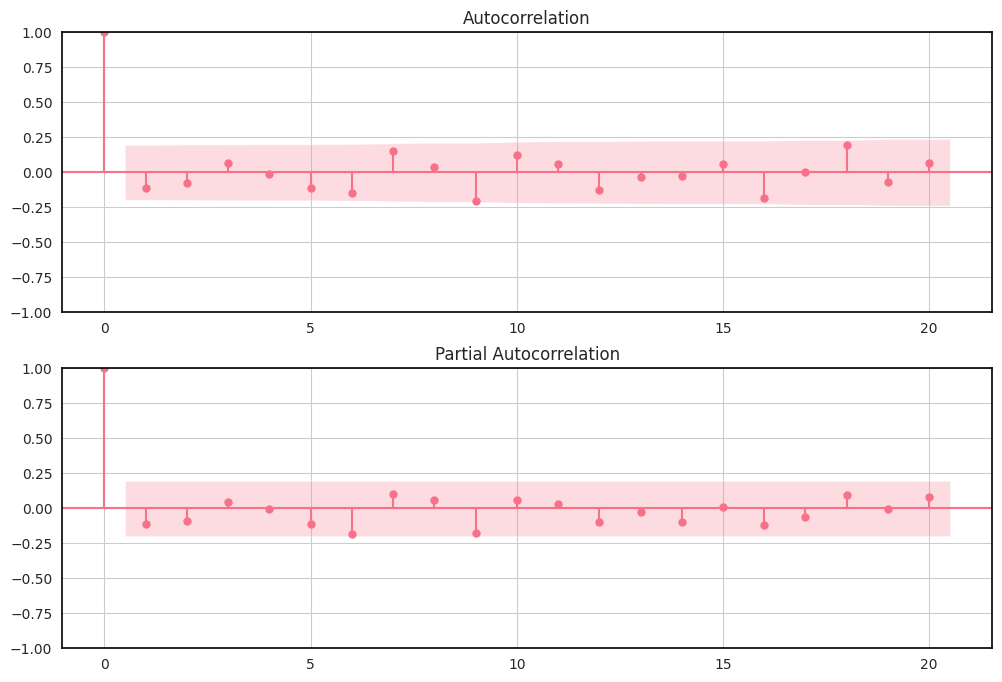

                               SARIMAX Results                                
Dep. Variable:             popularity   No. Observations:                  101
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -324.011
Date:                Mon, 09 Jun 2025   AIC                            656.022
Time:                        19:48:16   BIC                            666.483
Sample:                             0   HQIC                           660.257
                                - 101                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.0236      0.187    160.593      0.000      29.657      30.390
ar.L1          0.8703      0.081     10.708      0.000       0.711       1.030
ma.L1         -0.9999      8.453     -0.118      0.9

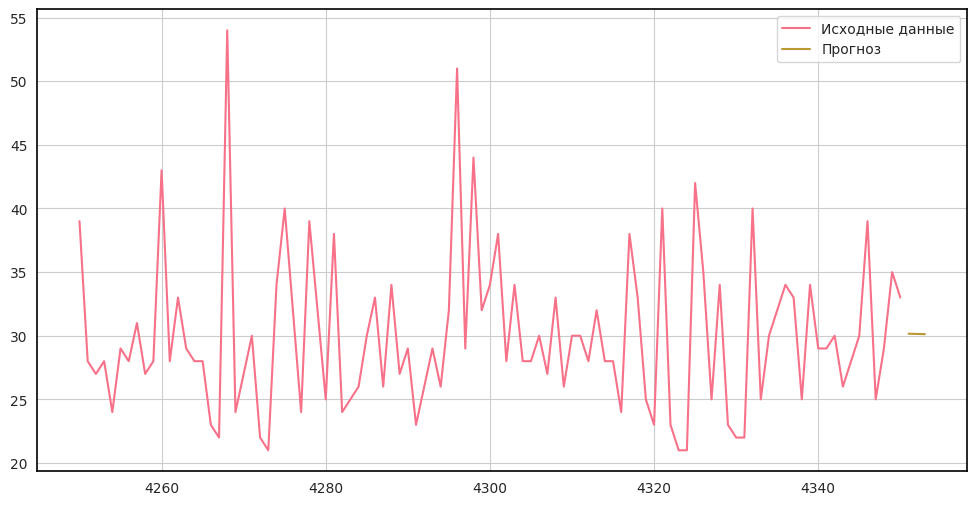

<ipython-input-35-c9c2becd14df>:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['mode'] = le.fit_transform(X['mode'])


                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.7126
Date:                Mon, 09 Jun 2025   Prob (F-statistic):              0.615
Time:                        19:48:17   Log-Likelihood:                -324.73
No. Observations:                 101   AIC:                             661.5
Df Residuals:                      95   BIC:                             677.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           33.2148      4.396      7.556   

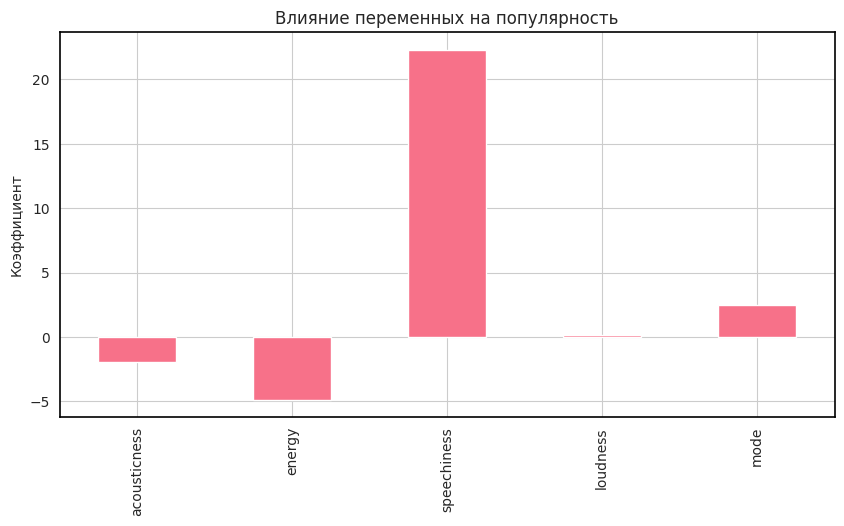

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from math import sqrt

def analyze_time_series(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] > 0.05:
        print("Ряд не стационарен, требуется дифференцирование")
        d = 1
        series_diff = series.diff().dropna()
    else:
        print("Ряд стационарен")
        d = 0
        series_diff = series
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(series_diff, lags=20, ax=ax1)
    plot_pacf(series_diff, lags=20, ax=ax2)
    plt.show()

    return d

d = analyze_time_series(df['popularity'])

def fit_arima(series, p, d, q):
    model = ARIMA(series, order=(p,d,q))
    model_fit = model.fit()
    print(model_fit.summary())
    forecast = model_fit.forecast(steps=3)
    print("Прогноз на 3 периода:", forecast)
    series.plot(figsize=(12,6), label='Исходные данные')
    forecast.plot(label='Прогноз')
    plt.legend()
    plt.show()

    return model_fit

arima_model = fit_arima(df['popularity'], 1, d, 1)
X = df[['acousticness', 'energy', 'speechiness', 'loudness', 'mode', 'time_signature']]
y = df['popularity']
le = LabelEncoder()
X['mode'] = le.fit_transform(X['mode'])
X = X.drop('time_signature', axis=1)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())
print("\nКоэффициенты модели:")
print(model.params)
plt.figure(figsize=(10,5))
model.params[1:].plot(kind='bar')
plt.title('Влияние переменных на популярность')
plt.ylabel('Коэффициент')
plt.show()

<ipython-input-5-40fd39b843d3>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2021-01-31', periods=len(y_ram), freq="M")


ADF: -8.23, P: 0.0000


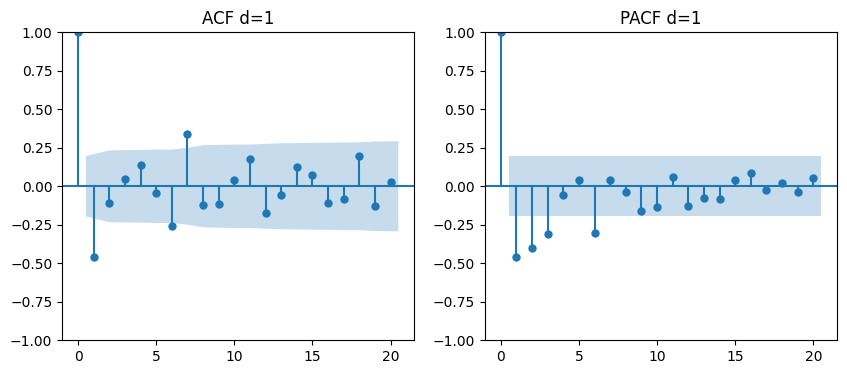

                               SARIMAX Results                                
Dep. Variable:             popularity   No. Observations:                   70
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -205.250
Date:                Tue, 10 Jun 2025   AIC                            416.499
Time:                        16:29:03   BIC                            423.201
Sample:                    01-31-2021   HQIC                           419.158
                         - 10-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0009      0.127      0.007      0.994      -0.249       0.250
ma.L1         -0.9999     24.840     -0.040      0.968     -49.685      47.686
sigma2        21.1173    523.966      0.040      0.9

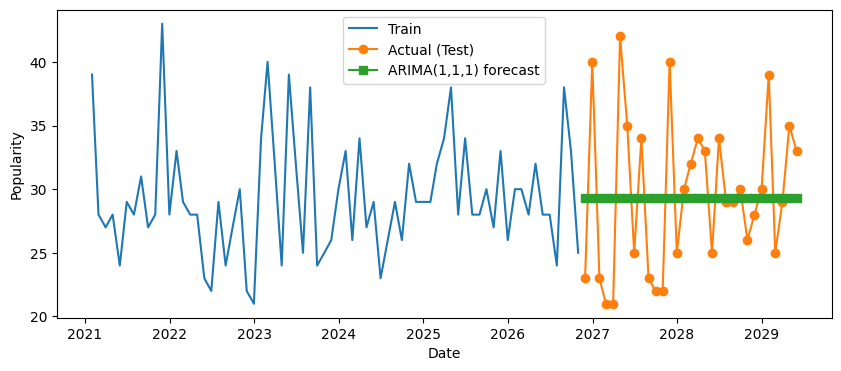

Среднее абсолютное отклонение (MAE): 4.98


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

y_ram = pd.to_numeric(df['popularity'], errors='coerce').dropna()

dates = pd.date_range('2021-01-31', periods=len(y_ram), freq="M")
series = pd.Series(y_ram.values, index=dates, name='popularity')

adf_stat, p_val, _, _, _, _ = adfuller(series)
print(f'ADF: {adf_stat:.2f}, P: {p_val:.4f}')

data_diff = series.diff().dropna()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(data_diff, lags=20, ax=ax[0]); ax[0].set_title('ACF d=1')
plot_pacf(data_diff, lags=20, ax=ax[1], method='ywm'); ax[1].set_title('PACF d=1')
plt.show()

train_size = int(len(series)*0.7)
train, test = series.iloc[:train_size], series.iloc[train_size:]

model = ARIMA(train, order=(1, 1, 1))
arima_fit = model.fit()
print(arima_fit.summary())

forecast = arima_fit.forecast(steps=len(test))

plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Actual (Test)', marker='o')
plt.plot(forecast, label='ARIMA(1,1,1) forecast', marker='s')
plt.ylabel('Popularity'); plt.xlabel('Date'); plt.legend(); plt.show()

mae = (abs(forecast - test)).mean()
print(f'Среднее абсолютное отклонение (MAE): {mae:.2f}')

In [ ]:
# Для более профессионального отображения добавьте:
from statsmodels.tsa.stattools import acf, pacf

# Расчет значений
acf_values = acf(data, nlags=20)
pacf_values = pacf(data, nlags=20)

# Вывод таблицы значений (как в вашем примере)
import pandas as pd
result_table = pd.DataFrame({
    'Lag': range(1, 21),
    'ACF': acf_values[1:21],
    'PACF': pacf_values[1:21]
})
print(result_table.round(4))

NameError: name 'data' is not defined

<ipython-input-14-f5ebea0c18f1>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2021-01-31', periods=len(y_ram), freq="M")


ADF: -8.23, P: 0.0000


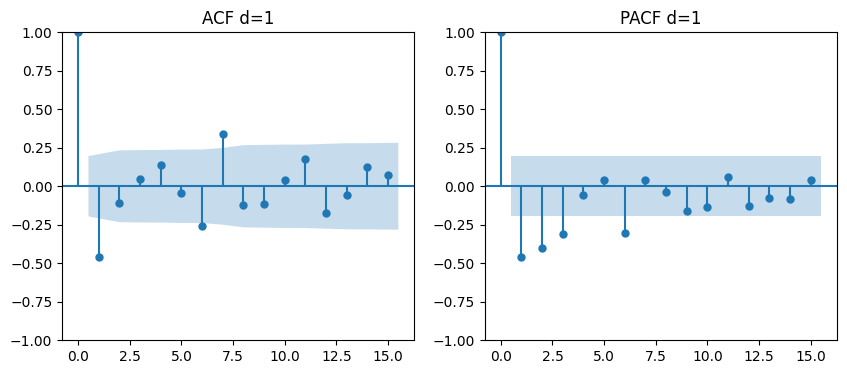

                               SARIMAX Results                                
Dep. Variable:             popularity   No. Observations:                   70
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -205.250
Date:                Tue, 10 Jun 2025   AIC                            416.499
Time:                        12:49:37   BIC                            423.201
Sample:                    01-31-2021   HQIC                           419.158
                         - 10-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0009      0.127      0.007      0.994      -0.249       0.250
ma.L1         -0.9999     24.840     -0.040      0.968     -49.685      47.686
sigma2        21.1173    523.966      0.040      0.9

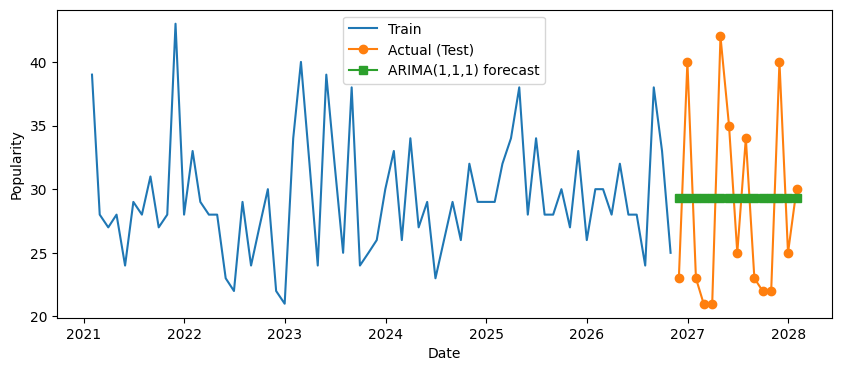

Среднее абсолютное отклонение (MAE): 6.93


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Загрузка и подготовка данных
y_ram = pd.to_numeric(df['popularity'], errors='coerce').dropna()
dates = pd.date_range('2021-01-31', periods=len(y_ram), freq="M")
series = pd.Series(y_ram.values, index=dates, name='popularity')

# Проверка стационарности
adf_stat, p_val, _, _, _, _ = adfuller(series)
print(f'ADF: {adf_stat:.2f}, P: {p_val:.4f}')

# Визуализация ACF и PACF для дифференцированного ряда
data_diff = series.diff().dropna()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(data_diff, lags=15, ax=ax[0]); ax[0].set_title('ACF d=1')
plot_pacf(data_diff, lags=15, ax=ax[1], method='ywm'); ax[1].set_title('PACF d=1')
plt.show()

# Разделение на train/test (70/30)
train_size = int(len(series)*0.7)
train, test = series.iloc[:train_size], series.iloc[train_size:]

# Обучение модели ARIMA(1,1,1)
model = ARIMA(train, order=(1, 1, 1))
arima_fit = model.fit()
print(arima_fit.summary())

# Прогноз на 3 периода вперед
forecast = arima_fit.forecast(steps=15)  # Изменено на steps=3

# Визуализация
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test.iloc[:15], label='Actual (Test)', marker='o')  # Только первые 3 точки
plt.plot(forecast, label='ARIMA(1,1,1) forecast', marker='s')
plt.ylabel('Popularity'); plt.xlabel('Date'); plt.legend(); plt.show()

# Оценка точности для 3 периодов
mae = (abs(forecast - test.iloc[:15])).mean()  # Сравнение с первыми 3 значениями
print(f'Среднее абсолютное отклонение (MAE): {mae:.2f}')

<ipython-input-10-12a903d0a717>:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2021-01-31', periods=len(y_ram), freq="M")


Проверка исходного ряда на стационарность:
ADF Statistic: -8.2318
p-value: 0.0000
Critical Values:
	1%: -3.4982
	5%: -2.8912
	10%: -2.5826
Ряд стационарен (отвергаем нулевую гипотезу)

Проверка дифференцированного ряда на стационарность:
ADF Statistic: -7.1794
p-value: 0.0000
Critical Values:
	1%: -3.5019
	5%: -2.8928
	10%: -2.5835
Ряд стационарен (отвергаем нулевую гипотезу)


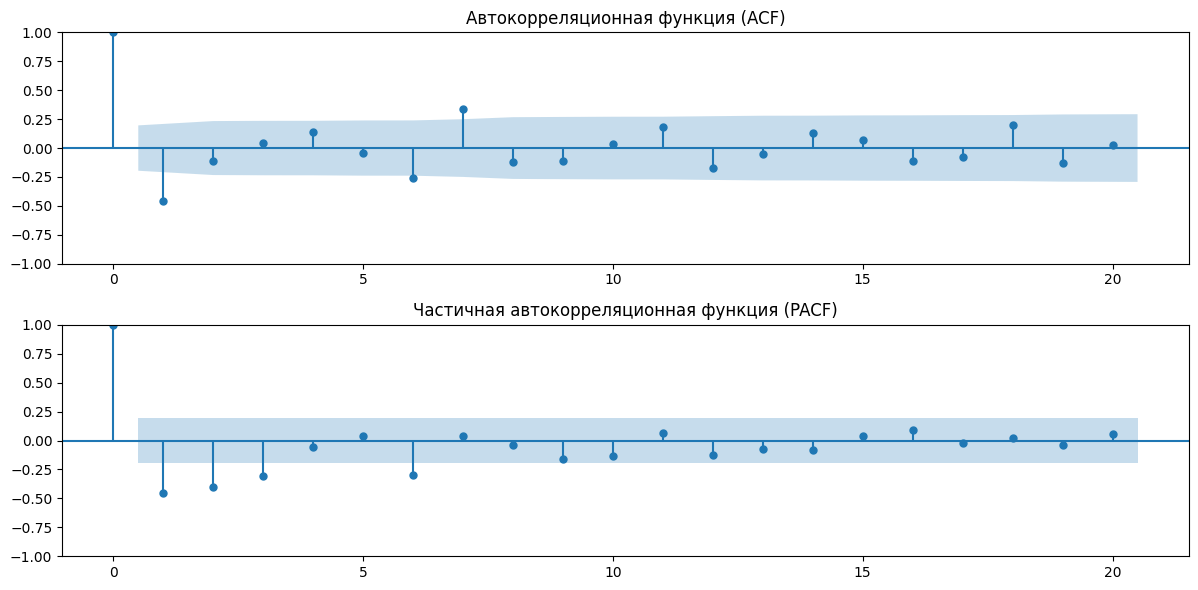

                               SARIMAX Results                                
Dep. Variable:             popularity   No. Observations:                   70
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -205.250
Date:                Tue, 10 Jun 2025   AIC                            416.499
Time:                        16:46:26   BIC                            423.201
Sample:                    01-31-2021   HQIC                           419.158
                         - 10-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0009      0.127      0.007      0.994      -0.249       0.250
ma.L1         -0.9999     24.840     -0.040      0.968     -49.685      47.686
sigma2        21.1173    523.966      0.040      0.9

<ipython-input-10-12a903d0a717>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=train.index[-1] + pd.DateOffset(months=1),


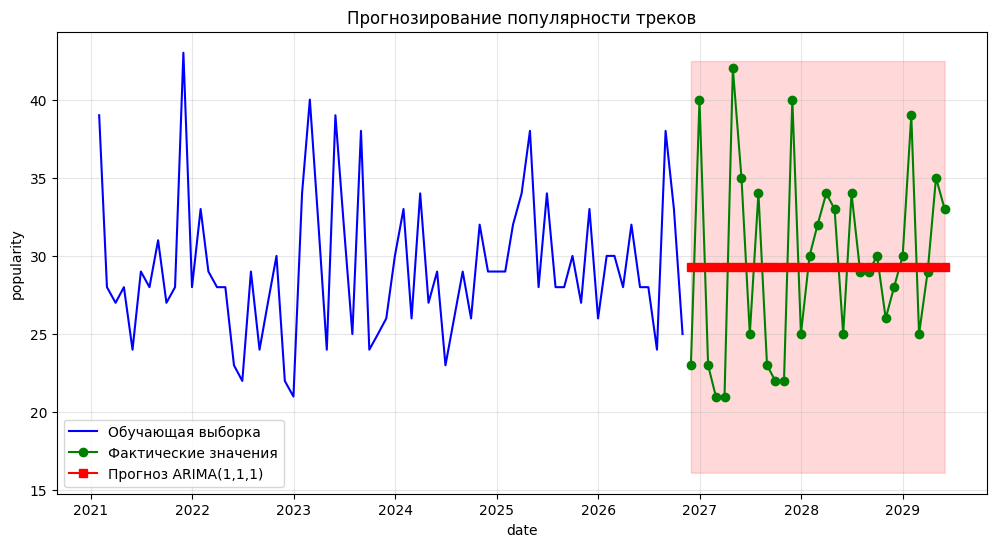


Средняя абсолютная ошибка (MAE): 4.98
Процент ошибки относительно среднего: 16.8%


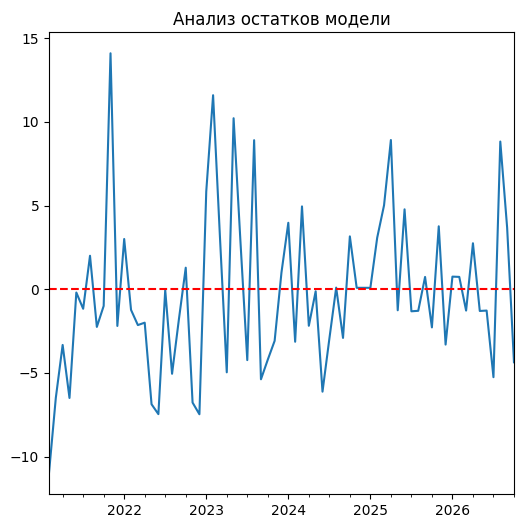

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Загрузка данных (предполагаем, что df уже существует)
y_ram = pd.to_numeric(df['popularity'], errors='coerce').dropna()

# Создание временного ряда с месячной частотой
dates = pd.date_range('2021-01-31', periods=len(y_ram), freq="M")
series = pd.Series(y_ram.values, index=dates, name='popularity')

# 1. Анализ стационарности
def check_stationarity(series):
    """Проверка стационарности с расширенным выводом"""
    adf_result = adfuller(series)
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'p-value: {adf_result[1]:.4f}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value:.4f}')

    if adf_result[1] <= 0.05:
        print("Ряд стационарен (отвергаем нулевую гипотезу)")
    else:
        print("Ряд нестационарен (не отвергаем нулевую гипотезу)")

print("Проверка исходного ряда на стационарность:")
check_stationarity(series)

# Дифференцирование ряда (d=1)
data_diff = series.diff().dropna()
print("\nПроверка дифференцированного ряда на стационарность:")
check_stationarity(data_diff)

# 2. Визуализация ACF/PACF
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(data_diff, lags=20, ax=plt.gca(), title='Автокорреляционная функция (ACF)')
plt.subplot(212)
plot_pacf(data_diff, lags=20, ax=plt.gca(), method='ywm', title='Частичная автокорреляционная функция (PACF)')
plt.tight_layout()
plt.show()

# 3. Разделение на train/test
train_size = int(len(series)*0.7)
train, test = series.iloc[:train_size], series.iloc[train_size:]

# 4. Подбор ARIMA модели
model = ARIMA(train, order=(1, 1, 1))
arima_fit = model.fit()

# Вывод полной статистики модели
print(arima_fit.summary())

# 5. Прогнозирование
forecast = arima_fit.forecast(steps=len(test))
forecast_index = pd.date_range(start=train.index[-1] + pd.DateOffset(months=1),
                             periods=len(test), freq='M')

# 6. Визуализация результатов
plt.figure(figsize=(12, 6))
plt.plot(train, label='Обучающая выборка', color='blue')
plt.plot(test, label='Фактические значения', color='green', marker='o')
plt.plot(forecast_index, forecast, label='Прогноз ARIMA(1,1,1)', color='red', marker='s')
plt.fill_between(forecast_index,
                forecast - 1.96*arima_fit.resid.std(),
                forecast + 1.96*arima_fit.resid.std(),
                color='red', alpha=0.15)
plt.title('Прогнозирование популярности треков')
plt.ylabel('popularity')
plt.xlabel('date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Оценка качества прогноза
mae = mean_absolute_error(test, forecast)
print(f'\nСредняя абсолютная ошибка (MAE): {mae:.2f}')
print(f'Процент ошибки относительно среднего: {mae/test.mean()*100:.1f}%')

# Дополнительно: анализ остатков модели
residuals = pd.Series(arima_fit.resid, index=train.index[1:])
plt.figure(figsize=(6, 6))
residuals.plot(title='Анализ остатков модели')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()